<h1 style="color: green;">Using Google Vision - Gemini on The Spiritualist Newspaper (1869 - 1882) </h1>

<p align="center">
  <img src="https://9to5google.com/wp-content/uploads/sites/4/2025/11/Gemini-3-family-cover.jpg?quality=82&strip=all&w=1600" width="500" alt="Gemini Logo">
</p>

This notebook was created in January 2026 for the National Library of Scotland (NLS) by Dr Joe Nockels, Digital Fellow. His related project, 'Recognising Text, Recognising Processes: eXplainable Automatic Text Recognition for Scottish Spiritualist Newspapers', was made possible through support from the NLS and Digital Humanities Institute (DHI), University of Sheffield. Images used of *The Spiritualist Newspaper* were first captured by the NLS Digitisation Unit in 2019, and made accessible as an open resource via the NLS Data Foundry
(https://data.nls.uk/data/digitised-collections/spiritualist-newspapers/). 

In extracting text from these images, this project conducted technical trials of available OCR engines representative of current developmental and business models, from open source applications to commercial LLMs. This also enabled improvements to be made on the NLS's 'dirty', inaccurate, legacy OCR for *The Spiritualist*.

This research aimed to establish how far Automatic Text Recognition can coalesce with 'eXplainable' developmental principles, and the extent to which such principles can aid non-technical library users in their understanding of how AI reaches its transcription results. As such, the project's OCR experiments occurred alongside a thematic coding of each tool's public-facing documentation, including how-to guides, model cards and GitHub README files, as well as other grey literature such as technical papers produced by developmental consortia. This was done through a bespoke web crawler using in-built request delays to ensure server compliance, with eXplainable themes coded via NVIVO (https://lumivero.com/products/nvivo/).

The resultant OCR transcription data created through this experimentation is hosted via a comparative web dashboard developed by the DHI. This platform enables visual and curatorial comparisons between each AI-enabled tool's transcription results, alongside interactive hosting of *The Spiritualist* images used. The site also provides a clear link to each OCR engine notebook. Together, the project team hope that such a resource will enable curators, library users and Digital Humanists to move beyond a purely single-score quantitative benchmarking of OCR tools, such as Character and Word Error Rate (CER/WER), toward a more curatorial assessment of AI-enabled transcription outputs, especially considering that AI-enabled transcription is now being applied to qualitative domains such as text interpretation and summarisation.

As further context, this Jupyter Notebook follows previous NLS projects using the format to provide introductory analyses to Data Foundry collections, in line with the OpenGLAM movement and Collections as Data principles (Ames & Havens, 2020). As with these projects, this work was conducted to encourage, enable and support computational research methods on collections, as well as meeting FAIR principles for digital research (https://www.go-fair.org/fair-principles/). The need for human-readable explanations for digital cultural heritage research, with Jupyter Notebooks being a prime example, was also expressed during the 2025 Bridging Responsible AI Divides Cultural Heritage Forum at Senate House Library, where initial findings from this OCR work were first presented.

In following FAIR principles, please contact Joe Nockels at j.nockels@sheffield.ac.uk if any of the following code requires clarification, troubleshooting, or - indeed - you would like to make use of the web crawler used on OCR documentation, entitled 'GhostCrawler'. 

<h4> About The Spiritualist Newspaper </h4>

*The Spiritualist Newspaper*, first published by E.W. Allen (London) in 1869, forms a key source for how those interested in physical investigations and spiritual forces communicated with the deceased, argued about criticism and issues, as well as publicised gatherings. The Newspaper followed a wake of spiritualist activity in Britain, directed by earlier 1850s American Transcendentalism and a more genral reaction to scientific naturalism. 

*The Spiritualist* was chosen as an OCR case study for several reasons: 

- Scottish spiritualist histories remain underrepresented, as Foot (2023) discusses. In our case, this partially results from historical detail being contained in heterogeneous and hard-to-transcribe material. This makes accurate OCR recognition more challenging, especially without requisite training data. With a fully searchable sample of 50 pages of *The Spiritualist* enabled through our OCR testing and reference, manually corrected, transcription, spiritualist activity outside of Scotland's Central Belt can be further explored. The trained reference model will also be applied to the entire collection as future work.

- In addition, Foot (2023: 73) suggests that seance mediums underwent 'automatic writing' to channel spiritual forces. The latter insight forms a neat parallel to charting the extent of unexplainable OCR processes in the current technical offering to libraries, as well as the potentially opaque behaviour and outputs of AI-enabled transcription models.

Alongside these two primary reasons, the project also aimed to provide metrics for the standardisation of OCR transcription at the NLS, with the Library currently undergoing a reassessment of its Foxit / ABBYY FineReader license. The timings registered through the below trials, alongside the CER of outputs, were used as an evidence base for NLS decision-making around digital collection transcription.

 -  **Data format**: png. manuscript images, pre-processed (thresholding and additional cropping) in R Studio using Image Magick. 
 -  **Data creation process**: GenAI / LLM Optical Character Recognition.
 - **Data source**: https://data.nls.uk/data/digitised-collections/spiritualist-newspapers/, 50 pages of the first 1869 edition.

<h4>Citations</h4>

- Foot, M. (2023) *Modern Spiritualism and Scottish Art - Scots, Spirits and Seances, 1860 - 1940.* London: Bloomsbury.
- Ames, S., Havens, L. (2022) Exploring National Library of Scotland datasets with Jupyter Notebooks, *International Federation of Library Associations and Institutions*, 48(1): 50-56. https://doi.org/10.1177/03400352211065484

<h4> Table of Contents </h4>

- <a href = '#section 0'><h6>About the Model</h6></a>
- <a href = '#section 1'><h6>Preparation</h6></a>
- <a href = '#section 2'><h6>OCR Processing</h6></a>
- <a href = '#section 3'><h6>Post-Processing</h6></a>

## <a href = '#section 0'><h4>About the Model and Current GenAI Debates</h4></a>

Google Cloud’s Vertex AI (https://docs.cloud.google.com/vision/docs) offers API integration with the company's GenAI model - Gemini-Pro-3. Gemini is described as a multimodal model used for tasks ranging from chat-based web crawling, image generation to Optical Character Recognition.

Alongside this, Google Cloud Vision, which allows solid Gemini-Pro-3 API integration into OCR workflows, has received prominent scholarly interest. This research interest also appears in accordance with the recent AI 'boom' driven by Large Language Models (LLMs) and Transformer-based architectures that can retain memory of prompted information through self-retention and back-propagation. With such developments, some in Digital History and the Digital Humanities have sinced declared that Google Vision has "Not just improved it [OCR on historical texts]" but "*solved it*", with the 2000s aspiration of having all historical material searchable online becoming a supposed reality once again (Scheinfeldt, 2025, https://foundhistory.org/handwriting-recognition-roundup/). Of course, such wishes do not account for collection appraisal, selection, and resourcing base digitisation, which OCR processing relies upon. In terms of comparing Google Cloud Vision to other text recognition platforms, despite citing remaining issues around accessibility, control, labour and historical interpretation in text recognition, Scheinfeldt (2025) continues: "I feel kind of terrible for the good folks at Transkribus, who have done, and continue to do, amazing work with human-trained transcription models. But I'm pretty confident that there will be room in the new paradigm for the careful, specific work their models perform". This provides an initial comparison, albeit an anecdotal one, between more traditional CNN architectures and community-built text recognition tools, and commercial LLMs.

Humphries (2025, https://generativehistory.substack.com/p/gemini-3-solves-handwriting-recognition) and Cohen (2025, https://newsletter.dancohen.org/archive/the-writing-is-on-the-wall-for-handwriting-recognition/) also reiterate this enthusiasm for Google Vision, with their quantitative benchmarking showing Gemini-Pro-3 to consitently produce text with errors comparable to expert human transcribers. Humphries's (2025) benchmarking against 10,0000 word tests, iterated 10 times each, produces a CER of 1.7% and WER of 4.42% (calculated externally via the co-developed application Transcription Pearl (https://github.com/mhumphries2323/Transcription_Pearl)), while Cohen's (2025) remarks prove more anecdotal and based on single-page tests from his own research. Nonetheless, the latter shows Gemini's potential for transcribing even cross-written text. Cohen (2025) also highlights the 'show thinking' tab as a potential resource for training students in pedagogical processes, with Gemini articulating its processing steps concurrently. 

For your own testing outside of this notebook, you can try out the Google Vision API via Google’s AI Studio: https://aistudio.google.com. 

In taking Google Vision's character recognition to be robust, Gribomont's (2023, https://programminghistorian.org/en/lessons/ocr-with-google-vision-and-tesseract) *Programming Historian* lesson combines the API with Tesseract layout analysis. Therefore, our experiment here is also not the first public use of Google Vision’s OCR on newspaper text from a humanities perspective. Comparative analyses also exist, with Kusmanto et al. (2024) testing Google Vision alongside Tesseract, showing the former model to achieve higher levels of accuracy, sensitivity and precision on newspaper text.

In 2023, Google Vision supported 60 languages, with 36 under active development and 133 mapped to another language code or a general character recogniser - such as indigenous, regional and historical lexicons (Gribomont, 2023). It is safe to say that the language registry is now greater than the 60 listed in 2023, with Google Vision's integration of Gemini bringing greater efficiences to the platform's layout analysis - a problem area cited by Gribomont (2023).

Nonetheless, with Gemini-Pro-3 running via the Google Cloud Platform - a Google account is required, with subsequent risk to research sustainability over the company's trackrecord for sunsetting tools. Google Cloud also has associated storage costs, alongside OCR processing, although these are minimal (around 1 pence for every 1 GB of storage every month). To avoid any potential billing headaches - Gribomont (2023) recommends deleting images from the server after the OCR process is completed. We use a free account in the following test.

Alongside processing cost deliberations, Google Vision still produces errors. This is expected with any AI-enabled trancription or collection processing on historical material, especially using degraded or heterogenous pages. However, as Hosseini et al. (2017) highlight, Google Vision can also struggle with image recognition and categorisation when minimal impulse noise is added. This raises questions over the security and potential risk of Google Vision processes at-scale, as well as the authenticity of its outputs. Though this may be less relevant to simple transcription tasks, it is worth bearing in mind against FAIR principles. Therefore, the following *Spiritualist* experiment, alongside the other OCRs tested as part of this fellowship, offer a benchmark for assessing the successes and vulnerabilities of cloud-based GenAI tool suites, necessary even for more conventional text extraction tasks. These GenAI tools, as McGregor (2025, https://libereurope.github.io/ds-topic-guides/ai-ml.html) discusses, are marketed toward the generation of new content, opposed to more traditional Machine Learning text conversion tasks, presenting a need to verify their errors beyond simplistic single-scored metrics. However, the *Spiritualist* images used should not be viewed as an 'adversarial' example, defined as a modified output still observable to the human-eye but created to stress test a system (Hosseini et al., 2017), with requisite pre-processing (thresholding, cropping) undertaken within R Studio to ensure as accurate results as possible from single-shot text recognition.

<h4>Citations</h4>

Hosseini, H., Xiao, B., Poovendran, R. 2017. Google’s Cloud Vision API Is Not Robust To Noise. Paper presented at the 16th IEEE International Conference on Machine Learning and Applications, 101-105, https://10.1109/ICMLA.2017.0-172

Kusmanto, B.T., Prakisya, N., Hatta, P. 2024. Comparative Analysis of Google Vision OCR with Tesseract on Newspaper Text Recognition. Media of Computer science (MCs), 1(1):31-46, 3063-4997, https://10.69616/mcs.v1i1.178 

<a href = '#section 1'><h4>Preparation</h4></a>

API Access - 

To utilise Google Vision (Gemini-Pro-3), first of all - log into the Google Cloud Console (https://console.cloud.google.com/) and enable the API from the left-hand-side menu. If budgeting credits, keep OCR processing to one *new* project file. In order to use this Jupyter Notebook, a Google service account needs establishing. You can locate this via the IAM and admin left-hand-side menu option within the console, or alternatively contact Joe Nockels at j.nockels@sheffield.ac.uk for access to the service account used here - depending on your processing need. In this case, the service account was named vision-ocr-sa but, if setting up your own, can be renamed freely. 

Privacy - 

After this, a service key needs establishing with the JSON exportation option selected. This key should be treated as a password, and should never be committed via Git or made public in any way. In this experiment's case, it was stored securely with the ~/.gcp/ file extension and remains obscured in the following code instructions. Another option is to write a .env file using touch.env within your terminal (provided you are using Mac OS) and nano .env to paste the sequence. 

Cost - 

As stated, Google Vision is not a free software, with the first 1,000 ‘units’ incurring no cost, and every 1,000 units thereafter costing approx. £1.20. Therefore, although we did not exceed the no cost limit, a billing account required linking to the service key and project via the Google Cloud Console. This Console also allows you to track processing costs.

**Step 1** - The below code initialises Google Vision's API for running within Jupyter, and imports packages for batch OCR processing. These packages include those for recording OCR processing times - needed for NLS decision-making around potential licencae replacements, as well as those for enabling a continuous .txt transcription export. The latter is needed to assess CER externally using CERberus (https://github.com/WHaverals/CERberus), a local host tool for calculating transcription errors away from tool environments - as a more neutral benchmark. The following packages also include those needed for ALTO XML and .csv exports. ALTO XML at page level is needed to ensure that the *Spiritualist* image hosted by the DHI are zoomable, and text present in the image interactive to the user.

We begin by loading the API key and then initialising the client, with a quick print check.

The required packages are then loaded.

In [1]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "os.path.expanduser("~/.gp_keys/vision_key.json")" # locked .gp file with limited access to service key

In [2]:
from google.cloud import vision

client = vision.ImageAnnotatorClient()
print("Vision client initialized successfully")

Vision client initialized successfully


In [3]:
# install the rest of the required packages, for recording page processing times, as well as enabling .txt, ALTO and csv. exportation

from pathlib import Path
from tqdm import tqdm
import time
import xml.etree.ElementTree as ET
import csv

**Step 2** - Now that the API key is initialised and the required packages for OCR processing and text exportation are imported, let us carry out a one page experiment to ensure the model is loaded and working.

In [4]:
client = vision.ImageAnnotatorClient()

# replace with your own image file path 

image_path = "/Users/joenockels/Documents/NLS_Fellowship (2025)/Spiritualist_Images/0001.png"

with open(image_path, "rb") as f:
    content = f.read()

image = vision.Image(content=content)

response = client.document_text_detection(image=image)

print(response.full_text_annotation.text[:1000])

The Spiritualist.
A RECORD OF THE PROGRESS OF THE SCIENCE AND ETHICS OF SPIRITUALISM.
No. 7.-VOL. I.
SPIRIT INFLUENCE.
LONDON TUESDAY, MARCH 15, 1870.
6
Published on the 15th of every
Month; Price Threepenee.
THE HANDLING OF RED-HOT COALS UNDER burned himself. Home then held it within four or five but it was quickly followed by raps, not only on the
inches of Mr. Saul's and Mr. Hurt's hands, and they table, but in different parts of the room; the table was
On one occasion, in the presence of four other wit- could not endure the heat. He came to me and said, moved up and down-lifted perfectly off the ground-
nesses, we saw the remarkable manifestation, so often Now if you are not afraid, hold out your hand.' I did made 'light' and 'heavy at the request of one or two
mentioned in the journals devoted to Spiritualism, of so, and having made two rapid passes over my hand, he of the gentlemen present; and, after the lapse of, I
I must have held it for half a suppose, nearly an hour, Mr. Hom

<a href = '#section 2'><h4>OCR Processing</h4></a>

**Step 1** - With the Gemini model verified as working via the API, we must construct a loop to ensure seamless processing over the remaining 50 page *Spiritualist* sample, as well as ensuring clean processing through handling API errors and the tracking of any additional processing costs.

In [5]:
# construct a loop function to perform the 50 pg. OCR task
def ocr_with_timing(path):
    start = time.time()
    
    with open(path, "rb") as f:
        content = f.read()

    image = vision.Image(content=content)
    response = client.document_text_detection(image=image)

    if response.error.message:
        raise RuntimeError(response.error.message) # defensive mechanism against the API, to over misplaced costings

    elapsed = time.time() - start
    return response.full_text_annotation, elapsed

**Step 2** - After constructing the loop, upload the *Spiritualist* image folder and verify that the expected 50 pages have been imported correctly.

In [6]:
# again, set this directory within your own local folder structure
image_dir = Path("/Users/joenockels/Documents/NLS_Fellowship (2025)/Spiritualist_Images")
pages = sorted(image_dir.glob("*.png")) # locates files with the .png extention, can be replaced with .jpeg or .pdf

print(f"Number of pages to OCR: {len(pages)}") # test that the image upload was performed correctly

Number of pages to OCR: 50


**Step 3** - We now need to construct the ALTO XML scaffolding (https://www.loc.gov/standards/alto/), that ensures - with some potential post-correction - the text and image coordinates match accurately. In our case, this is required for the DHI's hosting of *Spiritualist* images, alongside the produced .txt transcriptions created during each OCR test.

In [10]:
import xml.etree.ElementTree as ET

def vision_to_alto(annotation, image_name):
    """
    Convert a Google Vision full_text_annotation (.txt file) to ALTO XML.
    
    Args:
        annotation: vision.TextAnnotation (response.full_text_annotation)
        image_name: str, page identifier (used for ALTO ID)
    
    Returns:
        ET.ElementTree object representing the ALTO XML.
    """
    
    # Root ALTO element
    alto = ET.Element(
        "alto",
        {
            "xmlns": "http://www.loc.gov/standards/alto/ns-v4#",
            "xmlns:xsi": "http://www.w3.org/2001/XMLSchema-instance",
        }
    )
    
    layout = ET.SubElement(alto, "Layout")
    
    # Assume single page per annotation
    if not annotation.pages:
        raise ValueError("No pages found in annotation")
    
    page = annotation.pages[0]
    
    page_el = ET.SubElement(
        layout,
        "Page",
        {
            "ID": image_name,
            "PHYSICAL_IMG_NR": "1",
            "WIDTH": str(page.width or 0),
            "HEIGHT": str(page.height or 0),
        },
    )
    
    print_space = ET.SubElement(page_el, "PrintSpace")
    
    block_id = 0
    
    # Iterate over blocks
    for block in page.blocks:
        block_id += 1
        block_el = ET.SubElement(
            print_space,
            "TextBlock",
            {"ID": f"TB_{block_id}"}
        )
        
        # Iterate over paragraphs
        for paragraph in block.paragraphs:
            line_el = ET.SubElement(block_el, "TextLine")
            
            for word in paragraph.words:
                # Combine symbols into a word
                text = "".join(symbol.text for symbol in word.symbols).strip()
                if not text:
                    continue  # skip empty words
                
                # Safe bounding box extraction
                bbox = word.bounding_box.vertices
                x0 = bbox[0].x or 0
                y0 = bbox[0].y or 0
                x2 = bbox[2].x or 0
                y2 = bbox[2].y or 0
                width = x2 - x0
                height = y2 - y0
                
                ET.SubElement(
                    line_el,
                    "String",
                    {
                        "CONTENT": text,
                        "HPOS": str(x0),
                        "VPOS": str(y0),
                        "WIDTH": str(width),
                        "HEIGHT": str(height),
                    }
                )
    
    return ET.ElementTree(alto)


**Step 4** - With our ALTO scaffold prompt established, OCR processing loop constructed and API working correctly, the final step in this section is to begin the text recogniton process. We also need to initialise the timing for each page's processing, as a useful OCR performance benchmark.

Run the OCR by changing the below cell to = True. *Note - TRUE with Python is not recognised, avoid full capitalisation, and switch when ready to avoid misplaced costings.* 

Jupyter should produce verification of the export at page level, as well as the seconds taken to extract and write each page's transcription. The .txt file will be exported to the set wd in *Section 1* , along with page level ALTO XMl.

In [8]:
RUN_OCR = True  # safety switch, change to True when ready.

In [11]:
all_text = [] # empty lists for text outputs, and timings, to be populated as the loop carries out
timings = []

alto_dir = Path("alto_xml")
alto_dir.mkdir(exist_ok=True)

if RUN_OCR:
    batch_start = time.time()
     # establish error handling, in case a certain page cannot be processed
    for page_path in tqdm(pages):
        try:
            annotation, elapsed = ocr_with_timing(page_path)
        except RuntimeError as e:
            print(f"[ERROR] OCR failed for {page_path.name}: {e}")
            timings.append({"page": page_path.name, "seconds": None})
            continue

        # 1. Collect text together, append together as a final output
        all_text.append(annotation.text)

        # 2. Save ALTO XML using our Gen AI prompt scaffold
        alto_tree = vision_to_alto(annotation, page_path.stem)
        alto_path = alto_dir / f"{page_path.stem}.xml"
        alto_tree.write(alto_path, encoding="utf-8", xml_declaration=True)

        # 3. Log timing as a useful metric for NLS decision-making around OCR license replacements
        timings.append({
            "page": page_path.name,
            "seconds": round(elapsed, 3),
        })
    
    total_elapsed = time.time() - batch_start
    print(f"Total OCR time for {len(pages)} pages: {total_elapsed:.2f} seconds")

    with open("full_text.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(all_text))
        print(f"Full text saved to {text_file_path}")

    print(f"ALTO XML files are saved in: {alto_dir.resolve()}")

100%|███████████████████████████████████████████| 50/50 [18:55<00:00, 22.72s/it]

Total OCR time for 50 pages: 1135.97 seconds


<a href = '#section 3'><h4>Post-Processing and Evaluation</h4></a>

Finally, as verification against other OCR layout analysis algorithms, let us plot the boundary boxes used in the OCR processing workflow. This also provides a visual, curatorial insight, into how accurate our *Section 2* ALTO is likely to be at-scale.

This visual also indicates where transcription errors are likely to occur from page parsing errors, for instance the newspaper reading order being disrupted or columns failed to be recognised, before we calculate the eventual CER via the local host application CERberus (https://github.com/WHaverals/CERberus). Word units will be shown in red, paragraphs in blue, with broader text blocks (regions) in green. For newspaper processing, the latter dictates reading order and will likely have the biggest impact of CER when compared against a manually corrected reference string of the *Spiritualist*, outside of this notebook.

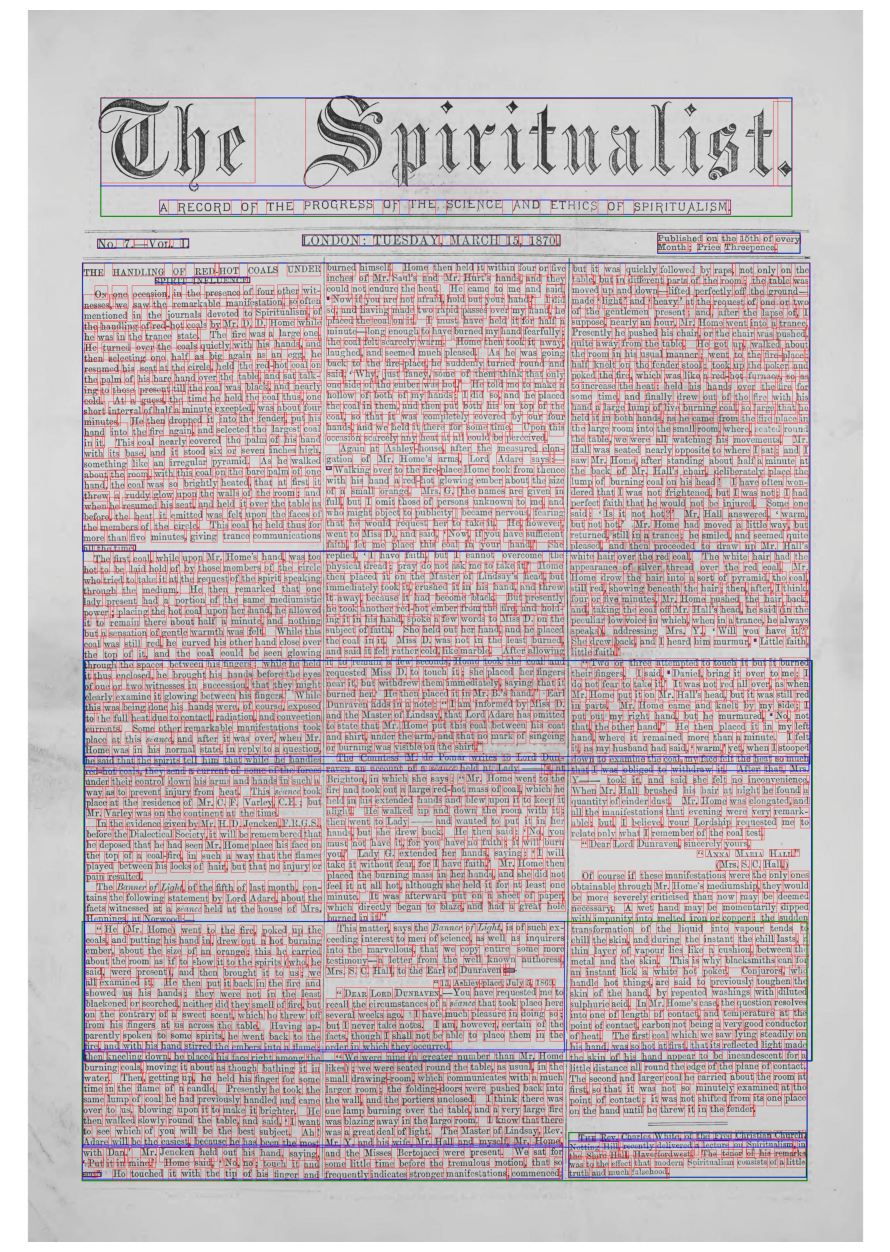

In [15]:
# import packages for visual boundary box plotting based on word coordinates

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Choose the first page, which is a title page - a robust case of different document structure levels

page_path = pages[0]
annotation, _ = ocr_with_timing(page_path)  # OR use your existing annotation, if available (for instance testing a marked up and labelled image)

# Open the original image
image = Image.open(page_path)
draw = ImageDraw.Draw(image)

# Colors for different hierarchy levels
colors = {
    "block": "green",
    "paragraph": "blue",
    "word": "red"
}

# Draw bounding boxes
for page in annotation.pages:
    for block in page.blocks:
        # Block bounding box
        bx0 = block.bounding_box.vertices[0].x or 0
        by0 = block.bounding_box.vertices[0].y or 0
        bx2 = block.bounding_box.vertices[2].x or 0
        by2 = block.bounding_box.vertices[2].y or 0
        draw.rectangle([bx0, by0, bx2, by2], outline=colors["block"], width=3)

        for paragraph in block.paragraphs:
            # Paragraph bounding box
            px0 = paragraph.bounding_box.vertices[0].x or 0
            py0 = paragraph.bounding_box.vertices[0].y or 0
            px2 = paragraph.bounding_box.vertices[2].x or 0
            py2 = paragraph.bounding_box.vertices[2].y or 0
            draw.rectangle([px0, py0, px2, py2], outline=colors["paragraph"], width=2)

            for word in paragraph.words:
                # Word bounding box
                wx0 = word.bounding_box.vertices[0].x or 0
                wy0 = word.bounding_box.vertices[0].y or 0
                wx2 = word.bounding_box.vertices[2].x or 0
                wy2 = word.bounding_box.vertices[2].y or 0
                draw.rectangle([wx0, wy0, wx2, wy2], outline=colors["word"], width=1)

# Show the image
plt.figure(figsize=(12, 16))
plt.imshow(image)
plt.axis("off")
plt.show()


Here, we can verify that the text recognition structure is roughly accurate without the use of OpenCV or similar graphic packages, however the paragraph structures appear to not split at the column boundary. However, the sequential processing of word units appears fairly accurate, in spite of this. This provides an initial guide for calculating our character error rates (CERs), presented as eventual research findings, and provides insight into whether document layout issues impact Gemini's accurate text extraction.

**Summary** - This code has provided a pipeline for uploading png. images of *The Spiritualist*, a 19th century newspaper taken from the National Library of Scotland's Data Foundry, for Gemini-Pro-3 OCR processing. We also provide an ALTO XML scaffold, as well as a method for layout analysis verification as post-processing evaluation. The exported plain .txt export will be used to generate CERs externally from this notebook and the Google Cloud, for reproducible comparisons to other Automatic Text Recognition (ATR) platforms as part of the NLS fellowship. The ALTO XML export will also be used for IIIF (https://iiif.io) compliant hosting via the DHI, collated at page level with other OCR outputs.

For any further guidance, comments or questions - contact Dr Joe Nockels at j.nockels@sheffield.ac.uk.